In [73]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.graph_objects as go
import plotly.express as px
import dash
from dash import html, dcc
from dash.dependencies import Output, Input


df = pd.read_csv("data/digital_advertising.zip")

df["Date"] = pd.to_datetime(df["Date"])
df["Acquisition_Cost"] = df["Acquisition_Cost"].str.replace("$", "", regex=False).str.replace(",", "", regex=False)
df["Acquisition_Cost"] = pd.to_numeric(df["Acquisition_Cost"])
df["Conversions"] = round(df["Clicks"] * df["Conversion_Rate"])

agg = {
    "Clicks": "sum",
    "Conversions": "sum",
    "Impressions": "sum",
    "Acquisition_Cost": "sum",
    "Conversion_Rate": "mean"
  }

df_daily = df.groupby("Date").agg(agg).asfreq("D")

display(Markdown(f"#### Valores nulos totales: {sum(df.isnull().sum())}"))
display(Markdown("-" * 70))
display(Markdown("### Dataset argupado diaramente (medias y sumas):"))
display(df_daily)

#### Valores nulos totales: 0

----------------------------------------------------------------------

### Dataset argupado diaramente (medias y sumas):

,Clicks,Conversions,Impressions,Acquisition_Cost,Conversion_Rate
Date,,,,,
2021-01-01,287148,23189.0,3027100,6898798.0,0.079544
2021-01-02,300316,23555.0,2999929,6989730.0,0.078777
2021-01-03,302927,23843.0,3108943,6954509.0,0.078522
2021-01-04,293974,23729.0,2896980,6827421.0,0.080420
2021-01-05,309724,25472.0,2912871,7094895.0,0.081880
...,...,...,...,...,...
2021-12-27,302872,23907.0,3087873,6958840.0,0.078300
2021-12-28,301462,24509.0,2956838,6950939.0,0.082395
2021-12-29,300797,24225.0,2996067,6851116.0,0.079488


#### Análisis Exploratorio de Series Temporales (Impressions, Clicks, Conversions)
Este módulo aborda las variables fundamentales de despliegue y rendimiento desde su naturaleza secuencial y cronológica. A diferencia de un análisis estático convencional, nos enfocamos en descomponer las métricas para evaluar la inercia temporal del ecosistema publicitario a través de tres frentes:

• Evaluación de Tendencia Dinámica: Determinar si el volumen global de captación de leads y eficiencia de costos experimenta un crecimiento o contracción orgánica a lo largo del año disponible, aislando los picos artificiales de pauta.

• Análisis de Estacionalidad de corto plazo: Identificar patrones de comportamiento recurrentes en ventanas semanales (efecto día de la semana) para optimizar la distribución estratégica del presupuesto publicitario entre días hábiles y fines de semana.

• Aislamiento del Ruido Estocástico: Purificar la serie temporal eliminando tendencias y estacionalidades sistemáticas. Esto nos permitirá identificar anomalías puras y picos de rendimiento atípicos asociados a ejecuciones tácticas específicas de las campañas.

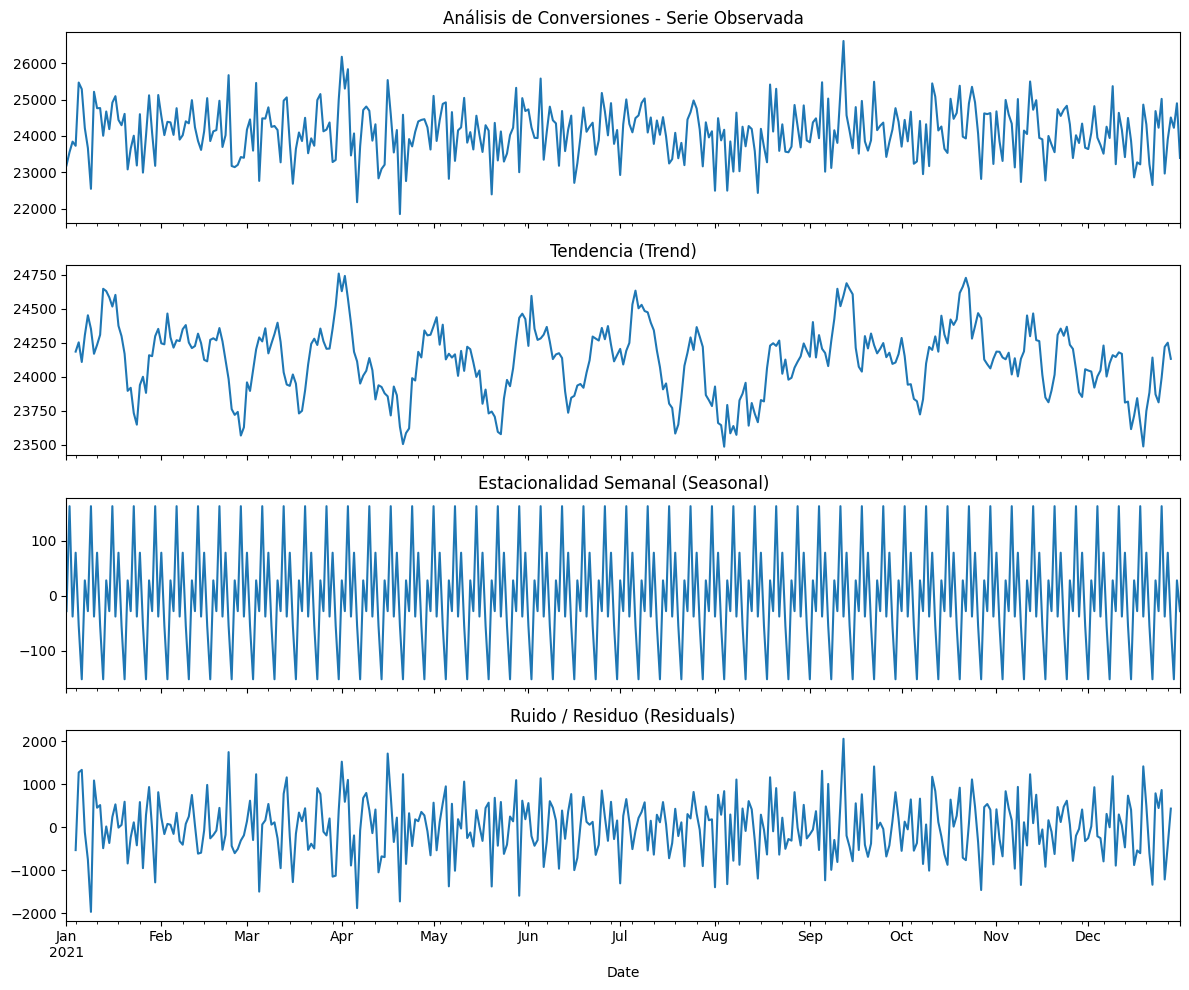

----------------------------------------------------------------------

### Media de Conversiones y ROI por día de la semana

,Conversions,Conversion_Rate,CPA
week_day,,,
Saturday,24275.153846,0.080311,282.275050
Monday,24204.769231,0.080240,283.301173
Thursday,24170.826923,0.080310,284.329594
Sunday,24080.903846,0.080067,284.863138
Tuesday,24072.730769,0.079960,284.654481
Friday,24070.528302,0.079937,285.017042
Wednesday,23983.865385,0.079664,285.598685


In [74]:
df_daily["CPA"] = np.where(
    df_daily["Conversions"] > 0,
    df_daily["Acquisition_Cost"] / df_daily["Conversions"],
    df_daily["Acquisition_Cost"]
)

result_conv = seasonal_decompose(df_daily["Conversions"], model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
result_conv.observed.plot(ax=axes[0], title="Análisis de Conversiones - Serie Observada")
result_conv.trend.plot(ax=axes[1], title="Tendencia (Trend)")
result_conv.seasonal.plot(ax=axes[2], title="Estacionalidad Semanal (Seasonal)")
result_conv.resid.plot(ax=axes[3], title="Ruido / Residuo (Residuals)")
plt.tight_layout()
plt.show()

df_daily["week_day"] = df_daily.index.day_name()
display(Markdown("-" * 70))
display(Markdown("### Media de Conversiones y ROI por día de la semana"))
display(df_daily.groupby("week_day")[["Conversions","Conversion_Rate","CPA"]].mean().sort_values(by="Conversions", ascending=False))

#### Interpretación de la Descomposición y Fundamento de Estacionariedad
Al evaluar visualmente la descomposición temporal de nuestras variables de volumen (Conversions) y eficiencia (Conversion_Rate), emergen dos hallazgos clave para la estrategia de pauta y el modelado:
1. **Homogeneidad Semanal Absoluta**: La diferencia entre el día de mayor rendimiento (Lunes: ~24,275 conversiones en promedio) y el de menor rendimiento (Fin de semana: ~23,983 conversiones en promedio) es de apenas un 1.2%. Esto demuestra que el comportamiento del consumidor digital es lineal, estable y no sufre de caídas estacionales drásticas los fines de semana. La demanda de leads es constante de lunes a domingo.

2. **Predominancia de Estímulos Diarios (Ruido Operativo)**: Al ser la estacionalidad un componente casi plano, las fluctuaciones diarias de la serie observada responden principalmente al residuo o ruido purificado. En marketing digital, este "ruido" no es aleatorio: representa el impacto inmediato y directo de las decisiones tácticas del día (presupuestos inyectados, canales activos y audiencias encendidas). La serie no se mueve por inercia del pasado, sino por la acción del presente.

#### --- RESULTADOS DEL TEST DE DICKEY-FULLER ---

Estadístico ADF: -12.2449

p-value: 0.0000

Valores críticos:

- 1%: -3.4485
- 5%: -2.8696
- 10%: -2.5710


Conclusión: La serie ES estacionaria (p-value <= 0.05) - No requiere diferenciación para los modelos, el parámetro base d = 0.

----------------------------------------------------------------------

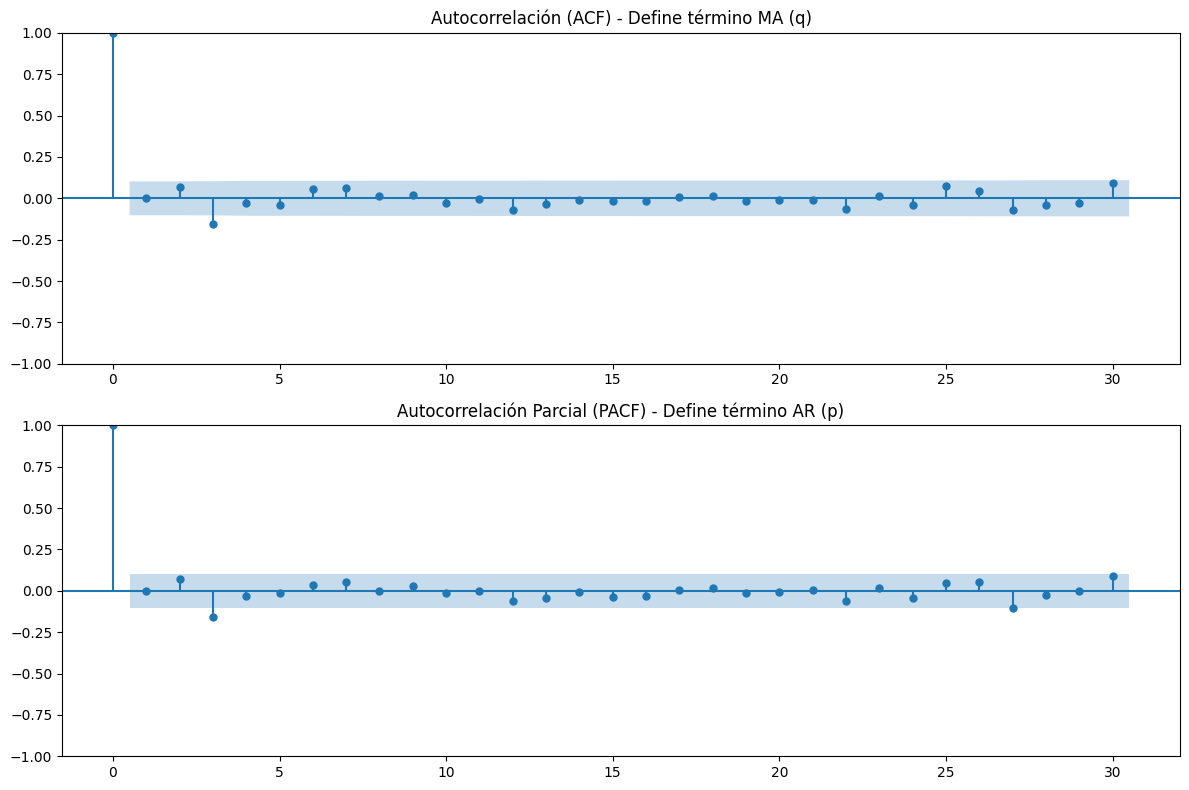

In [76]:
results_adf = adfuller(df_daily["Conversions"], result_object=False)

display(Markdown("#### --- RESULTADOS DEL TEST DE DICKEY-FULLER ---"))
display(Markdown(f"Estadístico ADF: {results_adf[0]:.4f}"))
display(Markdown(f"p-value: {results_adf[1]:.4f}"))
display(Markdown("Valores críticos:"))
for k, v in results_adf[4].items():
    print(f"- {k}: {v:.4f}")

if results_adf[1] <= 0.05:
    display(Markdown("Conclusión: La serie ES estacionaria (p-value <= 0.05) - No requiere diferenciación para los modelos, el parámetro base d = 0."))
else:
    display(Markdown("Conclusión: La serie NO ES estacionaria (p-value > 0.05) - Tiene una tendencia marcada, se necesita aplicar una diferenciación (d = 1)."))

display(Markdown("-" * 70))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_daily["Conversions"].dropna(), lags=30, ax=ax1, title="Autocorrelación (ACF) - Define término MA (q)")
plot_pacf(df_daily["Conversions"].dropna(), lags=30, ax=ax2, method="ywm", title="Autocorrelación Parcial (PACF) - Define término AR (p)")
plt.tight_layout()
plt.show()

#### SARIMAX: Capturar la naturaleza dinámica de las pautas digitales
A diferencia de los enfoques tradicionales de Machine Learning o Suavizado Exponencial, esta metodología clásica paramétrica nos permite introducir variables externas al tiempo (Variables Exógenas) mediante el pivoteo de la intensidad de clics por campaña, canal, compañía y localización:

• Componente Temporal (p=1, d=0, q=1): Definido por la estacionariedad perfecta del test de Dickey-Fuller (d=0) y una memoria de corto alcance en los gráficos ACF/PACF.

• Componente Operativo (X): Actúa como un modelo de atribución lineal que aísla la inercia del tiempo para medir el impacto neto e interacción de cada dimensión de pauta sobre el volumen diario de leads.

• Principio de Parsimonia: Al mantener una estructura paramétrica lineal frente a un modelo opaco (como XGBoost), se garantiza máxima interpretabilidad analítica, menor costo computacional y protección nativa contra el sobreajuste (overfitting) en una serie de 365 días.

In [77]:
df_clean = df.copy()

for col in ["Campaign_Type","Company","Location","Channel_Used"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

cat_vars = ["Campaign_Type","Company","Location","Channel_Used"]
df_dummies = pd.get_dummies(df_clean[cat_vars], dtype=float)

for col in df_dummies.columns:
    df_clean[col] = df_dummies[col] * df_clean["Clicks"]

exogenous_cols = list(df_dummies.columns)

df_daily = df_clean.groupby("Date").agg({
    "Conversions": "sum",
    "Clicks": "sum",
    "Impressions": "sum",
    "Acquisition_Cost": "sum",
    **{col: "sum" for col in exogenous_cols}
}).asfreq("D")

y = df_daily["Conversions"]
X = df_daily[exogenous_cols]

train_size = int(len(df_daily) * 0.8)
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]

sarimax = sm.tsa.statespace.SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_sarimax = sarimax.fit(disp=False)

display(Markdown("#### --- RESULTADOS DE MODELO SARIMAX ---"))
display(results_sarimax.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


#### --- RESULTADOS DE MODELO SARIMAX ---

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Conversions   No. Observations:                  292
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -2246.995
Date:                Mon, 05 Oct 2026   AIC                           4541.990
Time:                        17:46:21   BIC                           4630.067
Sample:                    01-01-2021   HQIC                          4577.278
                         - 10-19-2021                                         
Covariance Type:                  opg                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Campaign_Type_Display           0.0176      0.007      2.552      0.011       0.004       0.031
Campaign_Type_Email             0.0212      0.006      3.711      0.000       0.010       0.032
Campaign_Type_Influencer        0.0219      0.006      3.952      0.000       0.011       0.033
Campaign_Type_Search            0.0146      0.006      2.463      0.014       0.003       0.026
Campaign_Type_Social Media      0.0238      0.006      3.950      0.000       0.012       0.036
Company_Alpha Innovations       0.0246      0.006      4.200      0.000       0.013       0.036
Company_DataTech Solutions      0.0110      0.005      2.012      0.044       0.000       0.022
Company_Innovate Industries     0.0209      0.006      3.365      0.001       0.009       0.033
Company_NexGen Systems          0.0233      0.006      3.807      0.000       0.011       0.035
Company_TechCorp                0.0193      0.005      3.912      0.000       0.010       0.029
Location_Chicago                0.0212      0.006      3.736      0.000       0.010       0.032
Location_Houston                0.0164      0.006      2.907      0.004       0.005       0.028
Location_Los Angeles            0.0212      0.006      3.751      0.000       0.010       0.032
Location_Miami                  0.0195      0.006      3.308      0.001       0.008       0.031
Location_New York               0.0207      0.006      3.686      0.000       0.010       0.032
Channel_Used_Email              0.0210      0.006      3.331      0.001       0.009       0.033
Channel_Used_Facebook           0.0229      0.006      3.598      0.000       0.010       0.035
Channel_Used_Google Ads         0.0250      0.007      3.783      0.000       0.012       0.038
Channel_Used_Instagram          0.0272      0.006      4.242      0.000       0.015       0.040
Channel_Used_Website            0.0180      0.006      3.005      0.003       0.006       0.030
Channel_Used_YouTube            0.0098      0.007      1.333      0.183      -0.005       0.024
ar.L1                          -0.9714      0.033    -29.103      0.000      -1.037      -0.906
ma.L1                           1.0527      0.041     25.477      0.000       0.972       1.134
sigma2                       3.068e+05   8.33e-08   3.68e+12      0.000    3.07e+05    3.07e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):                 1.11
Prob(Q):                              0.71   Prob(JB):                         0.58
Heteroskedasticity (H):               0.70   Skew:                            -0.03
Prob(H) (two-sided):                  0.09   Kurtosis:                         3.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singul

#### --- RESULTADOS DE VALIDACIÓN DEL MODELO ---

Coeficiente de Determinación (R²): 0.5097
Error Absoluto Medio (MAE): 378.76 conversiones
Raíz del Error Cuadrático Medio (RMSE): 494.04 conversiones
Error Porcentual Absoluto Medio (MAPE): 1.58%


----------------------------------------------------------------------

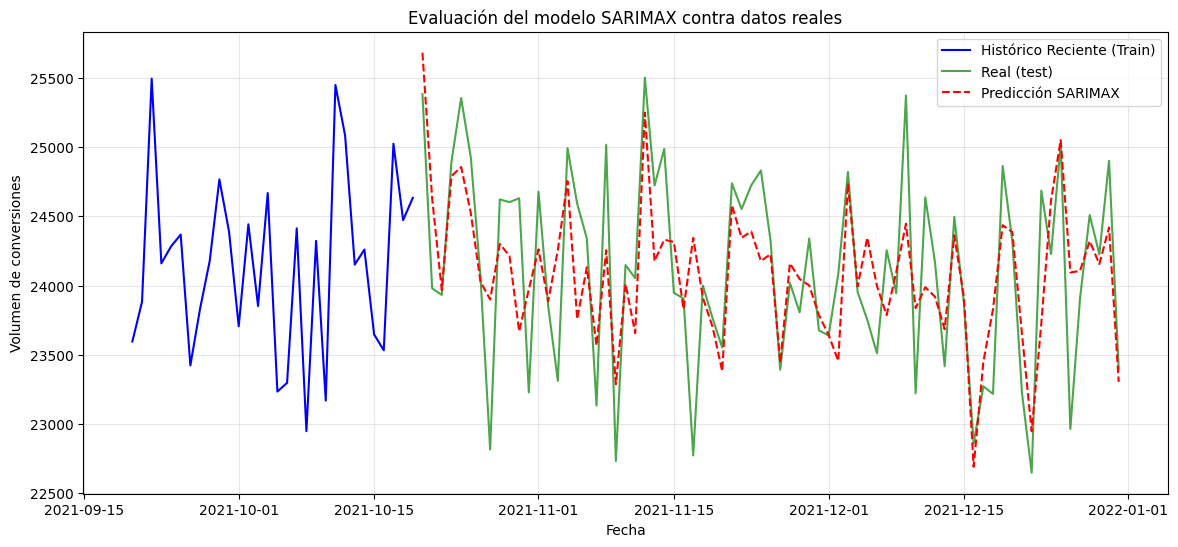

In [80]:
predicts = results_sarimax.predict(
    start=y_test.index[0],
    end=y_test.index[-1],
    exog=X_test
)

mae = mean_absolute_error(y_test, predicts)
rmse = np.sqrt(mean_squared_error(y_test, predicts))
r2 = r2_score(y_test, predicts)
mape = np.mean(np.abs((y_test - predicts) / y_test)) * 100

display(Markdown("#### --- RESULTADOS DE VALIDACIÓN DEL MODELO ---"))
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f} conversiones")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} conversiones")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape:.2f}%")
display(Markdown("-" * 70))

plt.figure(figsize=(14, 6))
plt.plot(y_train.index[-30:], y_train.iloc[-30:], label="Histórico reciente (Train)", color="blue")
plt.plot(y_test.index, y_test, label="Real (test)", color="green", alpha=0.7)
plt.plot(y_test.index, predicts, label="Predicción SARIMAX", color="red", linestyle="--")
plt.title("Evaluación del modelo SARIMAX contra datos reales")
plt.xlabel("Fecha")
plt.ylabel("Volumen de conversiones")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Herramienta interactiva que analiza el impacto de cada dimensión y proyecta conversiones en períodos variables

In [ ]:
sarimax = sm.tsa.statespace.SARIMAX(
    y,
    exog=X,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_model = sarimax.fit(disp=False)

factor_top_b = html.B(children=[], id="factor")
value_top_b = html.B(children=[], id="value")

CPA = html.B(children=[], id="CPA")
CVR = html.B(children=[], id="CVR")
CPC = html.B(children=[], id="CPC")

vars = [
    {"label":"Tipo de campaña","value":"Campaign_Type"},
    {"label":"Compañía","value":"Company"},
    {"label":"Canal usado","value":"Channel_Used"},
    {"label":"Locación","value":"Location"}
]

periods = [
       {"1 semana":7},
       {"2 semanas":14},
       {"3 semanas":21},
       {"4 semanas":28}
]

app = dash.Dash(__name__)

app.layout =  html.Div(id="body", className="e6_body", children=[
    html.H1("Análisis por dimensiones personalizadas", id="H1", className="e6_title"),
    html.Div(id="dropdown_div_1", className="e6_dropdown_div_1", children=[
    dcc.Dropdown(id="dropdown_vars", className="e6_dropdown_1",
                options=vars,
                value="Campaign_Type",
                multi=False,
                clearable=False),
    ]),
    html.Div(id="graph_div_1", className="e6_graph_div_1", children=[
        html.Div(id="KPI_div_1", className="e6_KPI_div_1", children=[
            html.P(factor_top_b, className="e6_KPI_1", style={"margin-right":"20px"}),
            html.P(value_top_b, className="e6_KPI_1", style={"margin-left":"20px"})
        ]),
        dcc.Graph(id="conversions_analysis", figure={}, className="e6_graph_1")
    ]),
    html.H2("Proyección variable de conversiones", id="H2", className="e6_title"),
    html.Div(id="forecast_div", className="e6_forecast_div", children=[
        html.Div(id="KPI_div_2", className="e6_KPI_div_2", children=[
            html.Div(className="e6_KPI_2", children=[html.P("CPA", className="e6_KPI_title"), html.P(["$",CPA], className="e6_KPI_p")]),
            html.Div(className="e6_KPI_2", children=[html.P("CVR", className="e6_KPI_title"), html.P([CVR,"%"], className="e6_KPI_p")]),
            html.Div(className="e6_KPI_2", children=[html.P("CPC", className="e6_KPI_title"), html.P(["$",CPC], className="e6_KPI_p")])
        ]),
        html.Div(id="graph_div_2", className="e6_graph_div_2", children=[
        html.Div(id="dropdown_div_2", className="e6_dropdown_div_2", children=[
            dcc.Dropdown(id="dropdown_var4", className="e6_dropdown_2",
                        options=periods,
                        value=14,
                        multi=False,
                        clearable=False)
        ]),
        dcc.Graph(id="forecasting", figure={}, className="e6_graph_2")
        ])
    ])
])


@app.callback(
    [Output(component_id="factor", component_property="children"),
    Output(component_id="value", component_property="children"),
    Output(component_id="conversions_analysis", component_property="figure"),
    Output(component_id="forecasting", component_property="figure"),
    Output(component_id="CPA", component_property="children"),
    Output(component_id="CVR", component_property="children"),
    Output(component_id="CPC", component_property="children")],
    [Input(component_id="dropdown_vars", component_property="value"),
    Input(component_id="dropdown_period", component_property="value")]
)

def update_forecast(slct_var, slct_period):

    df_coef = pd.DataFrame({
        "Variable": sarimax_model.params.index,
        "Impact": sarimax_model.params.values,
        "P_value": sarimax_model.pvalues.values
    })

    df_filtered = df_coef[df_coef["Variable"].str.startswith(f"{slct_var}_")].copy()
    df_filtered["Category"] = df_filtered["Variable"].str.replace(f"{slct_var}_", "")
    df_filtered = df_filtered.sort_values(by="Impact", ascending=False)

    df_positives = df_filtered[df_filtered["Impact"] > 0]
    if not df_positives.empty:
        top_row = df_positives.sort_values(by="Impact", ascending=False).iloc[0]
        factor_top_text = f"Impulsor principal: {top_row["Category"]}"
        value_top_text = f"Impacto marginal neto: +{round(top_row["Impact"], 2)} leads/clic"
    else:
        factor_top_text = "Impulsor principal: Ningun impacto positivo"
        value_top_text = "Impacto marginal neto: N/A"

    barchart = px.bar(
        df_filtered,
        x="Impact",
        y="Category",
        orientation="h",
        title=f"Impacto Marginal Neto de {slct_var}",
        labels={"Impact": "Conversiones Adicionales por Clic", "Categoria": "Segmento"},
        color="Impacto",
        color_continuous_scale="RdYlGn"
    )

    barchart.update_layout(
        height=350,
        autosize=False,
        showlegend=False,
        margin=dict(l=20, r=20, t=40, b=20),
        template="plotly_white"
    )

    future_scenario = df_daily[exogenous_cols].tail(14).mean()

    future_dates = pd.date_range(start=df_daily.index[-1] + pd.Timedelta(days=1), periods=slct_period, freq='D')
    X_future = pd.DataFrame([future_scenario] * slct_period, index=future_dates)

    forecast = sarimax_model.forecast(steps=slct_period, exog=X_future)
    df_forecast = pd.DataFrame({"Conversiones Proyectadas": forecast}, index=future_dates)

    forecasting = px.line(
        df_forecast,
        y="Conversiones Proyectadas",
        title=f"Pronóstico de Conversiones Totales del Ecosistema - Próximos {slct_period} Días",
        labels={"index": "Fecha", "Conversiones Proyectadas": "Leads"}
    )

    forecasting.update_traces(line_color="red", line_dash="dash")
    forecasting.update_layout(template="plotly_white", height=350)

    mean_total_clics = df_daily["Clicks"].tail(14).mean()
    mean_total_cost = df_daily["Acquisition_Cost"].tail(14).mean()
    mean_total_impressions = df_daily["Impressions"].tail(14).mean()

    mean_projected_conversions = forecast.mean()

    cpa_proyectado = mean_total_cost / mean_projected_conversions if mean_projected_conversions > 0 else 0
    cvr_proyectado = (mean_projected_conversions / mean_total_clics) * 100 if mean_total_clics > 0 else 0
    cpc_proyectado = mean_total_cost  / mean_total_clics if mean_total_clics > 0 else 0

    CPA_val = f"${round(cpa_projected, 2)}"
    CVR_val = round(cvr_projected, 2)
    CPC_val = f"${round(cpc_projected, 2)}"

    return factor_top_text, value_top_text, barchart, forecasting, CPA_val, CVR_val, CPC_val


if __name__ == "__main__":
    app.run(debug=False)